## Plot JPDF, divJPDF by latitude band

In [1]:
import xarray as xr

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Open the data

In [3]:
hist_ds = xr.open_dataset('data/hist_full.nc',chunks={})

In [4]:
lat_bin_edges = np.asarray([-80,-55,-30, -15, 15, 30, 55, 80])
denom_region_weights = ((hist_ds['region_wet_area'])).groupby_bins('lat', lat_bin_edges).mean(dim='region')
h_vs_lat = (hist_ds['probability_density']*(hist_ds['region_wet_area'])).groupby_bins('lat', lat_bin_edges).mean(dim='region').isel(time=slice(11,20)).mean('time')/denom_region_weights
h_vs_lat_aso =(hist_ds['probability_density']*(hist_ds['region_wet_area'])).groupby_bins('lat', lat_bin_edges).mean(dim='region').roll(time=5,roll_coords=True).isel(time=slice(0,10)).mean('time')/denom_region_weights

## Expectation values

In [5]:
def marginalize(pdf: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Integrate out one or more dimensions of the PDF to remove dependence on that quantity,
    whilst still preserving the total integrated probability.
    """
       
    all_bin_dims = ['vort_bin', 'strain_bin', 'div_bin']
    
    if isinstance(dims, str):
        dims = [dims]
    
    if dims is None:
        dims=all_bin_dims
    
    if any(d not in all_bin_dims for d in dims):
        raise ValueError("Can't take marginal PDF over a dimension which is not a variable of the original PDF")
    
    marginal_pdf = pdf

    # TODO these might be more accurate if we used xarray's integrate function
    if 'vort_bin' in dims:
        vort_bin_width = pdf['vort_bin'].diff('vort_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='vort_bin') * vort_bin_width
        
    if 'strain_bin' in dims:
        strain_bin_width = pdf['strain_bin'].diff('strain_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='strain_bin') * strain_bin_width
        
    if 'div_bin' in dims:
        div_bin_width = pdf['div_bin'].diff('div_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='div_bin') * div_bin_width
        
    return marginal_pdf


def expectation(pdf: xr.DataArray, x: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Take the expectation value of x over the given Probability Density Function.
    """
    
    return marginalize(pdf * x, dims=dims)

In [6]:
@xr.register_dataarray_accessor("pdf")
class DataArrayPDFAccessor:
    def __init__(self, da: xr.DataArray):
        self._da = da
        
    def marginalize(self, dims: str | list = None) -> xr.DataArray:
        return marginalize(self._da, dims=dims)
    
    def expectation(self, x, dims: str | list = None) -> xr.DataArray:
        return expectation(self._da, x, dims=dims)

In [7]:


h_vort_strain_vs_lat = h_vs_lat.pdf.marginalize('div_bin')
h_vort_strain_vs_lat_aso = h_vs_lat_aso.pdf.marginalize('div_bin')

In [8]:
h_vort_strain_vs_lat = h_vs_lat.pdf.marginalize('div_bin')
h_vort_strain_vs_lat_aso = h_vs_lat_aso.pdf.marginalize('div_bin')

In [9]:
#Be cautious: this cell takes about 7GB of memory
h_vs_lat1 = h_vort_strain_vs_lat[:,:,::-1]*(hist_ds['vort_bin'].diff('vort_bin')[0]*hist_ds['strain_bin'].diff('strain_bin')[0])
h_vs_lat1.load()
h_vs_lat1_aso = h_vort_strain_vs_lat_aso[:,:,::-1]*(hist_ds['vort_bin'].diff('vort_bin')[0]*hist_ds['strain_bin'].diff('strain_bin')[0])
h_vs_lat1_aso.load()

<xarray.DataArray (vort_bin: 99, strain_bin: 49, lat_bins: 7)> Size: 272kB
array([[[1.82710484e-07, 1.61725733e-07, 4.82904256e-08, ...,
         8.91025764e-08, 0.00000000e+00, 0.00000000e+00],
        [6.34847509e-07, 4.98206515e-07, 5.79477089e-07, ...,
         1.33685515e-07, 1.32012818e-07, 1.46661171e-07],
        [5.05451566e-07, 8.98529086e-07, 5.73038197e-07, ...,
         2.22756442e-07, 2.16164953e-07, 1.29275913e-07],
        ...,
        [3.34503092e-06, 3.02352891e-06, 2.21566960e-06, ...,
         4.90159119e-07, 9.88004594e-07, 7.92047633e-07],
        [2.61755864e-06, 2.81384156e-06, 2.03467128e-06, ...,
         5.34720956e-07, 1.20792614e-06, 8.45907373e-07],
        [3.28735682e-06, 2.88575879e-06, 2.05277096e-06, ...,
         5.34668211e-07, 8.74756185e-07, 8.57715354e-07]],

       [[2.01203506e-07, 1.15811207e-07, 4.82823947e-08, ...,
         0.00000000e+00, 4.92342622e-08, 0.00000000e+00],
        [9.57405420e-08, 8.18310528e-07, 4.20650853e-07, ...,
         2.45069011e-07, 1.37242808e-07, 1.46661171e-07],
        [7.53646103e-07, 9.79541991e-07, 7.59758331e-07, ...,
         3.11848464e-07, 5.20629746e-07, 3.02381550e-07],
...
         2.14881774e-06, 3.30456489e-06, 2.65015895e-06],
        [3.21379021e-06, 3.59979404e-06, 2.92144025e-06, ...,
         2.21566872e-06, 3.37245955e-06, 2.71927079e-06],
        [3.98117215e-06, 3.72788526e-06, 3.00829193e-06, ...,
         2.08882558e-06, 3.47085944e-06, 2.51880043e-06]],

       [[4.73398493e-08, 2.05556506e-07, 2.41452135e-07, ...,
         1.33643311e-07, 2.68372615e-07, 6.04772285e-08],
        [3.79145490e-08, 7.38875325e-07, 5.07037448e-07, ...,
         3.11869559e-07, 2.57918032e-07, 1.03569200e-07],
        [8.71182794e-07, 1.07537805e-06, 6.72834339e-07, ...,
         4.45523430e-07, 3.79169397e-07, 2.07138401e-07],
        ...,
        [3.56221405e-06, 3.58744101e-06, 2.61985650e-06, ...,
         2.06490160e-06, 2.91448376e-06, 2.66943045e-06],
        [3.36827198e-06, 3.31319644e-06, 2.71383142e-06, ...,
         2.07861645e-06, 3.19537682e-06, 2.50577118e-06],
        [3.42400150e-06, 3.31176878e-06, 2.59810922e-06, ...,
         1.88494763e-06, 3.29475301e-06, 2.42343640e-06]]],
      shape=(99, 49, 7))
Coordinates:
  * vort_bin    (vort_bin) float64 792B -4.949 -4.848 -4.747 ... 4.848 4.949
  * strain_bin  (strain_bin) float64 392B 0.05102 0.1531 0.2551 ... 4.847 4.949
  * lat_bins    (lat_bins) interval[int64, right] 112B (55, 80] ... (-80, -55]
    div_bin     float64 8B -4.848

In [10]:
h_vs_lat1 = h_vs_lat1.where(h_vs_lat1>10**-5).load()
h_vs_lat1_aso = h_vs_lat1_aso.where(h_vs_lat1_aso>10**-5).load()

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\s'
<>:90: SyntaxWarning: invalid escape sequence '\s'
<>:127: SyntaxWarning: invalid escape sequence '\s'
<>:164: SyntaxWarning: invalid escape sequence '\s'
<>:201: SyntaxWarning: invalid escape sequence '\s'
<>:237: SyntaxWarning: invalid escape sequence '\s'
<>:246: SyntaxWarning: invalid escape sequence '\z'
<>:265: SyntaxWarning: invalid escape sequence '\z'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\s'
<>:90: SyntaxWarning: invalid escape sequence '\s'
<>:127: SyntaxWarning: invalid escape sequence '\s'
<>:164: SyntaxWarning: invalid escape sequence '\s'
<>:201: SyntaxWarning: invalid escape sequence '\s'
<>:237: SyntaxWarning: invalid escape sequence '\s'
<>:246: SyntaxWarning: invalid escape sequence '\z'
<>:265: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_1454/721742172.py:17: SyntaxWarning: invalid escape seq

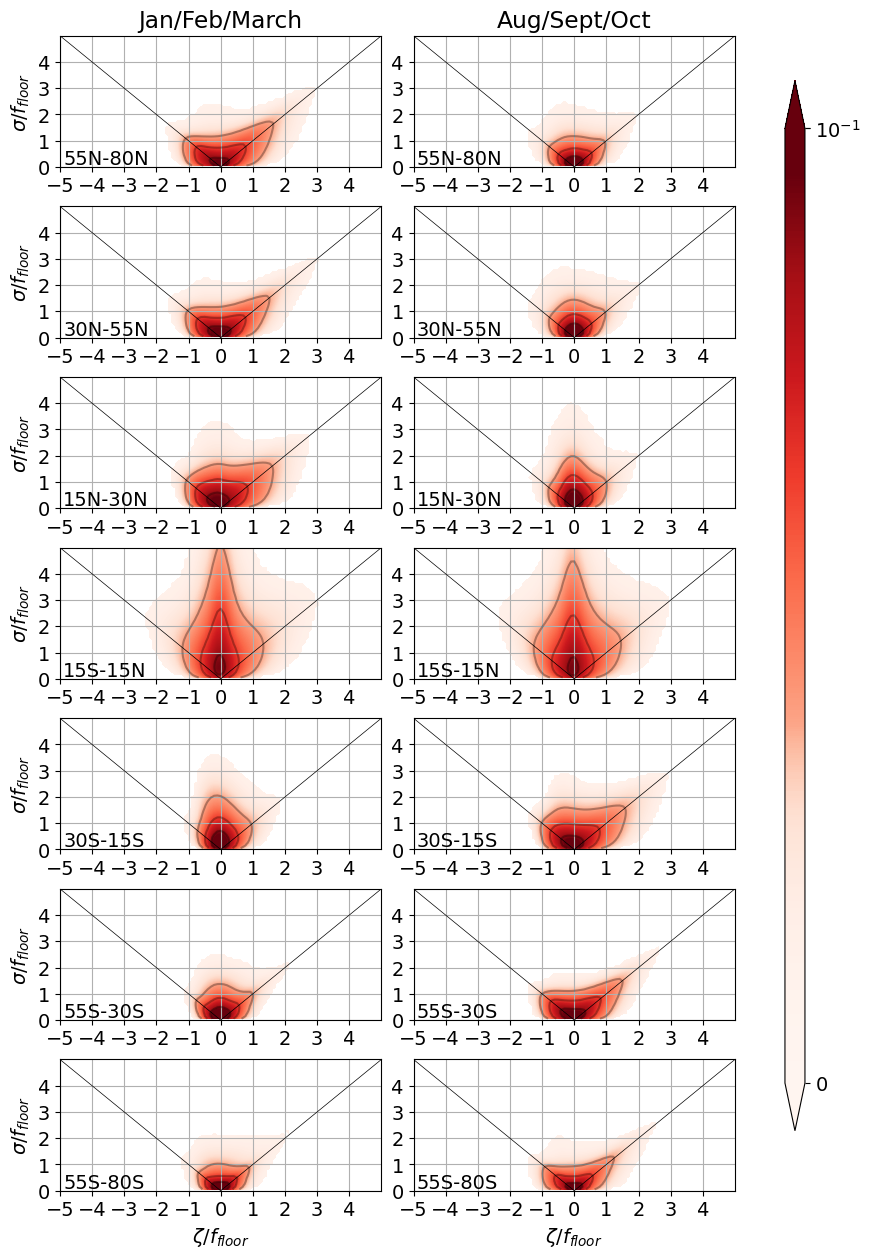

In [11]:
import matplotlib.colors as cols

plt.rcParams.update({'font.size': 14})

plt.figure(figsize=(10,15))
plt.clf()
plt.subplot(721)

levels = 10**(np.arange(-5.5, -1.5, 0.01))
h_vs_lat1.isel(lat_bins=0).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1.isel(lat_bins=0).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("Jan/Feb/March")
plt.text(-4.9, 0.1, "55N-80N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(722)
h_vs_lat1_aso.isel(lat_bins=0).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=0).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("Aug/Sept/Oct")
plt.text(-4.9, 0.1, "55N-80N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(723)
h_vs_lat1.isel(lat_bins=1).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1.isel(lat_bins=1).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.text(-4.9, 0.1, "30N-55N")
plt.title("")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(724)
h_vs_lat1_aso.isel(lat_bins=1).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=1).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.text(-4.9, 0.1, "30N-55N")
plt.title("")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()


plt.subplot(725)
h_vs_lat1.isel(lat_bins=2).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1.isel(lat_bins=2).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "15N-30N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(726)
h_vs_lat1_aso.isel(lat_bins=2).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=2).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "15N-30N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()


plt.subplot(727)
h_vs_lat1.isel(lat_bins=3).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1.isel(lat_bins=3).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "15S-15N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(728)
h_vs_lat1_aso.isel(lat_bins=3).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=3).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "15S-15N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()


plt.subplot(729)
h_vs_lat1.isel(lat_bins=4).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1.isel(lat_bins=4).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "30S-15S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(7,2,10)
h_vs_lat1_aso.isel(lat_bins=4).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=4).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "30S-15S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()


plt.subplot(7,2,11)
h_vs_lat1.isel(lat_bins=5).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1.isel(lat_bins=5).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "55S-30S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(7,2,12)
h_vs_lat1_aso.isel(lat_bins=5).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=5).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "55S-30S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(7,2,13)
h_vs_lat1.isel(lat_bins=6).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1.isel(lat_bins=6).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "55S-80S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')

plt.subplot(7,2,14)
cs = h_vs_lat1_aso.isel(lat_bins=6).plot.contourf(x='vort_bin', vmax=0.02,norm=cols.SymLogNorm(1e-4), cmap='Reds',
                    vmin=10**-5.5,levels=levels,extend='both',add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=6).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "55S-80S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')

fig = plt.gcf()

log_formatter = mticker.LogFormatterMathtext(base=10)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
fig.colorbar(cs, cax=cbar_ax,format= log_formatter, ticks= [0, 5*10**-2, 10**-1])
plt.subplots_adjust(right=0.8, hspace=0.3, wspace=0.1)


plt.savefig('lat_jpdf.png')
plt.show()

In [ ]:
hdiv_vs_lat = (((h_vs_lat*h_vs_lat.div_bin).sum('div_bin')/h_vs_lat.sum('div_bin'))[:,:,::-1]).load()
hdiv_vs_lat_aso = (((h_vs_lat_aso*h_vs_lat_aso.div_bin).sum('div_bin')/h_vs_lat_aso.sum('div_bin'))[:,:,::-1]).load()

In [ ]:
hdiv_vs_lat2 = hdiv_vs_lat.where(h_vs_lat1>10**-5).load()
hdiv_vs_lat2_aso = hdiv_vs_lat_aso.where(h_vs_lat1_aso>10**-5).load()

In [ ]:
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(10,15))
plt.clf()
plt.subplot(721)

levels = 10**(np.arange(-5.5, -1.5, 0.01))
hdiv_vs_lat2.isel(lat_bins=0).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1.isel(lat_bins=0).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("Jan/Feb/March")
plt.text(-4.9, 0.1, "55N-80N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(722)
hdiv_vs_lat2_aso.isel(lat_bins=0).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=0).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("Aug/Sept/Oct")
plt.text(-4.9, 0.1, "55N-80N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(723)
hdiv_vs_lat2.isel(lat_bins=1).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1.isel(lat_bins=1).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.text(-4.9, 0.1, "30N-55N")
plt.title("")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(724)
hdiv_vs_lat2_aso.isel(lat_bins=1).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=1).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.text(-4.9, 0.1, "30N-55N")
plt.title("")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(725)
hdiv_vs_lat2.isel(lat_bins=2).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1.isel(lat_bins=2).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "15N-30N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(726)
hdiv_vs_lat2_aso.isel(lat_bins=2).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=2).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "15N-30N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(727)
hdiv_vs_lat2.isel(lat_bins=3).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1.isel(lat_bins=3).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "15S-15N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(728)
hdiv_vs_lat2_aso.isel(lat_bins=3).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=3).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "15S-15N")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(729)
hdiv_vs_lat2.isel(lat_bins=4).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1.isel(lat_bins=4).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "30S-15S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(7,2,10)
hdiv_vs_lat2_aso.isel(lat_bins=4).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=4).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "30S-15S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(7,2,11)
hdiv_vs_lat2.isel(lat_bins=5).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1.isel(lat_bins=5).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "55S-30S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(7,2,12)
hdiv_vs_lat2_aso.isel(lat_bins=5).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=5).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "55S-30S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()

plt.subplot(7,2,13)
hdiv_vs_lat2.isel(lat_bins=6).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1.isel(lat_bins=6).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('$\sigma/f_{floor}$')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "55S-80S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')

plt.subplot(7,2,14)
cs = hdiv_vs_lat2_aso.isel(lat_bins=6).plot(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_vs_lat1_aso.isel(lat_bins=6).plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.5)
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=0.5)
plt.xlim(-5,5)
plt.ylim(0,5)
plt.ylabel('')#
plt.xlabel('')
plt.title("")
plt.text(-4.9, 0.1, "55S-80S")
x_ticks = np.arange(-5, 5)
y_ticks = np.arange(0, 5)
plt.gca().set_xticks(x_ticks)
plt.gca().set_yticks(y_ticks)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')

fig = plt.gcf()

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
fig.colorbar(cs, cax=cbar_ax)
plt.subplots_adjust(right=0.8, hspace=0.3, wspace=0.1)


plt.savefig('lat_divjpdf.png')
plt.show()